# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.6 MB/s eta 0:00:00


In [2]:
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import cv2

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple
import math
import random

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

In [3]:
from torchvision.models import resnet18, ResNet18_Weights
import torchsummary
import torchmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Descarga del dataset

In [4]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  62.2M      0  0:00:01  0:00:01 --:--:--  103M


In [5]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [6]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## Data Augmentation

En esta sección se aplica el mismo `data augmentation` que se definió en la sección `EDA - Definición de Transformaciones y Data Augmentation` de la notebook [trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

Comenzamos obteniendo las media y desvío estándar del dataset de `train`, a fin de utilizarlas para normalizar las imágenes:

In [7]:
# basic_transform = transforms.Compose([
#     transforms.Resize((128, 128)),
#     transforms.ToTensor(),
# ])

# train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)

# train_loader_for_stats = DataLoader(train_data, batch_size=64, shuffle=False)

# def get_mean_std(loader):
#     """
#     Calcula la media y la desviación estándar por canal (RGB) de un
#     conjunto de datos cargado por un DataLoader.
#     """
#     channels_sum, channels_sqrd_sum, num_batches = 0, 0, 0

#     print("Calculando media y std del dataset de train...")
#     for data, _ in loader:
#         channels_sum += torch.mean(data, dim=[0, 2, 3])
#         channels_sqrd_sum += torch.mean(data**2, dim=[0, 2, 3])
#         num_batches += 1

#     mean = channels_sum / num_batches
#     std = (channels_sqrd_sum / num_batches - mean**2)**0.5
#     return mean, std

# dataset_mean, dataset_std = get_mean_std(train_loader_for_stats)

Se definen las mismas transformaciones que en la sección `Definición de Transformaciones y Data Augmentation` de la notebook [trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

In [8]:
dataset_mean = [0.485, 0.456, 0.406]
dataset_std = [0.229, 0.224, 0.225]


In [9]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

## Definición de datasets para los modelos

In [10]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [11]:
BATCH_SIZE = 32

In [12]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

## Función para train-test loop

A continuación, se define el *loop* principal de entrenamiento. Este proceso iterará sobre el número de `EPOCHS` definido.

En cada época, se realizan dos fases:

1.  **Fase de Entrenamiento (`model.train()`):**
    * Se itera sobre el `train_loader`.
    * Se realiza el *forward pass* (propagación hacia adelante).
    * Se calcula la pérdida (***Loss***) comparando las predicciones con las etiquetas reales (usando `criterion`).
    * Se realiza el *backward pass* (retropropagación) y se actualizan los pesos del modelo (`optimizer.step()`).
    * Se acumulan la *loss* y las métricas de esta fase.

2.  **Fase de Validación (`model.eval()`):**
    * Se desactiva el cálculo de gradientes (`with torch.no_grad()`) para ahorrar cómputo, ya que en esta fase no se aprende.
    * Se itera sobre el `validation_loader`.
    * Se evalúa el rendimiento del modelo sobre datos "no vistos" (el conjunto de validación).
    * Se acumulan la *loss* y las métricas de validación.

Además, se implementará un mecanismo de **Early Stopping**. Este monitoreará la pérdida de validación (`val_loss`) y detendrá el entrenamiento si esta no mejora después de un número determinado de épocas (`patience`), evitando así el *overfitting* y ahorrando tiempo de cómputo.

Se almacenará el historial de *loss* y métricas de ambas fases en cada época para su posterior visualización.

In [13]:
# def train_eval_loop(model: any, optimizer, criterion, metric,
#                     data: dict, epochs: int = 100, tb_writer: dict = None):
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#     train_loader = data["train"]
#     valid_loader = data["valid"]

#     if tb_writer:
#         train_writer = tb_writer["train"]
#         valid_writer = tb_writer["valid"]

#         train_writer.add_graph(model, torch.zeros((1, data["image_channels"],
#                                                      data["image_width"],
#                                                      data["image_height"])))
#         valid_writer.add_graph(model, torch.zeros((1, data["image_channels"],
#                                                      data["image_width"],
#                                                      data["image_height"])))
#     model.to(device)
#     metric.to(device)

#     train_loss = []
#     train_metric = []
#     valid_loss = []
#     valid_metric = []

#     patience = 5  # Número de épocas de paciencia antes de detenerse
#     best_val_loss = float('inf') # Se busca minimizar la loss de validación
#     epochs_no_improve = 0
#     # ----------------------------------------

#     # (La variable 'history' se crea al final, con los resultados)

#     # Corregido: Usar 'epochs' (argumento) en lugar de 'EPOCHS' (indefinido)
#     print(f"Iniciando entrenamiento por {epochs} épocas...")
#     print(f"Early Stopping activado con paciencia de {patience} épocas.")

#     for epoch in range(epochs):

#         ####################  TRAIN  ####################
#         model.train()

#         epoch_train_loss = 0.0
#         epoch_train_metric = 0.0

#         for train_data, train_target in train_loader:

#             train_data = train_data.to(device)
#             train_target = train_target.to(device)

#             optimizer.zero_grad()
#             output = model(train_data.float())
#             loss = criterion(output, train_target)
#             epoch_train_loss += loss.item()
#             loss.backward()
#             optimizer.step()

#             epoch_train_metric += metric(output, train_target).item()

#         epoch_train_loss = epoch_train_loss / len(train_loader)
#         epoch_train_metric = epoch_train_metric / len(train_loader)
#         train_loss.append(epoch_train_loss)
#         train_metric.append(epoch_train_metric)

#         ####################  EVAL  ####################
#         model.eval()

#         epoch_valid_loss = 0.0
#         epoch_valid_metric = 0.0

#         all_preds = torch.tensor([]).to(device)
#         all_labels = torch.tensor([]).to(device)

#         # Desactivamos gradientes para la validación
#         with torch.no_grad():
#             for valid_data, valid_target in valid_loader:
#                 valid_data = valid_data.to(device)
#                 valid_target = valid_target.to(device)

#                 output = model(valid_data.float())
#                 epoch_valid_loss += criterion(output, valid_target).item()
#                 epoch_valid_metric += metric(output, valid_target).item()

#                 all_preds = torch.cat((all_preds, output))
#                 all_labels = torch.cat((all_labels, valid_target))

#         epoch_valid_loss = epoch_valid_loss / len(valid_loader)
#         epoch_valid_metric = epoch_valid_metric / len(valid_loader)
#         valid_loss.append(epoch_valid_loss)
#         valid_metric.append(epoch_valid_metric)

#         print("Epoch: {}/{} - Train loss {:.6f} - Train Metric {:.6f} - Valid Loss {:.6f} - Valid Metric {:.6f}".format(
#         epoch+1, epochs, epoch_train_loss, epoch_train_metric, epoch_valid_loss, epoch_valid_metric))

#         if tb_writer:
#             train_writer.add_scalar("loss", epoch_train_loss, epoch)
#             valid_writer.add_scalar("loss", epoch_valid_loss, epoch)
#             train_writer.add_scalar("metric", epoch_train_metric, epoch)
#             valid_writer.add_scalar("metric", epoch_valid_metric, epoch)
#             train_writer.flush()
#             valid_writer.flush()

#         # --- Lógica de Early Stopping ---
#         if epoch_valid_loss < best_val_loss:
#             print(f"    Mejora en Val Loss: ({best_val_loss:.4f} --> {epoch_valid_loss:.4f}). Guardando modelo...")
#             best_val_loss = epoch_valid_loss
#             epochs_no_improve = 0
#             # Opcional: guardar el mejor modelo
#             # torch.save(model.state_dict(), 'best_model.pth')
#         else:
#             epochs_no_improve += 1
#             print(f"    No hay mejora en Val Loss por {epochs_no_improve} épocas.")

#         if epochs_no_improve == patience:
#             print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
#             break  # Se rompe el loop 'for epoch...'
#         # ----------------------------------

#     # Se arma el diccionario 'history' al final, con los resultados
#     history = {}
#     history["train_loss"] = train_loss
#     history["train_metric"] = train_metric
#     history["valid_loss"] = valid_loss
#     history["valid_metric"] = valid_metric
#     history["labels_last_epoch"] = all_labels
#     history["pred_last_epoch"] = all_preds

#     return history

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device, metric):
    model.train()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_outputs.append(outputs.detach())
        all_targets.append(labels.detach())

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = metric(outputs_cat, targets_cat).item()

    return epoch_loss, epoch_recall

In [15]:
def eval_one_epoch(model, loader, criterion, device, metric):
    model.eval()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            all_outputs.append(outputs)
            all_targets.append(labels)

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = metric(outputs_cat, targets_cat).item()

    return epoch_loss, epoch_recall, outputs_cat, targets_cat


In [16]:
def train_eval_loop(model: any, optimizer, criterion, metric, data: dict,
                    epochs: int = 100, patience: int = 5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_metric": [],
        "valid_metric": [],
        "labels_last_epoch": [],
        "pred_last_epoch": [],
        "test_loss": 0,
        "test_metric": 0,
    }

    train_loader = data["train"]
    valid_loader = data["valid"]

    model.to(device)
    metric.to(device)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(epochs):
      ####################  TRAIN STEP  ####################
      train_loss, train_recall = train_one_epoch(
          model, train_loader, optimizer, criterion, device, metric
      )

      ####################  EVAL STEP  ####################
      valid_loss, valid_recall, _, _ = eval_one_epoch(
          model, valid_loader, criterion, device, metric
      )

      ####################  Métricas del EPOCH  ####################

      history["train_loss"].append(train_loss)
      history["valid_loss"].append(valid_loss)
      history["train_metric"].append(train_recall)
      history["valid_metric"].append(valid_recall)

      ####################  EARLY STOPPING  ####################
      if valid_loss < best_val_loss:
        print(
            f"Época {epoch+1}/{epochs} | "
            f"Train loss: {train_loss:.4f} - Train recall: {train_recall:.4f} | "
            f"Valid loss: {valid_loss:.4f} - Valid recall: {valid_recall:.4f}"
        )
        best_val_loss = valid_loss
        epochs_no_improve = 0
      else:
        epochs_no_improve += 1
        print(f"=====No hay mejora en Valid Loss por {epochs_no_improve} épocas.")

      if epochs_no_improve == patience:
        print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
        break

    ####################  TEST  ####################
    test_loader = data["test"]
    test_loss, test_metric, test_outputs, test_targets = eval_one_epoch(
        model, test_loader, criterion, device, metric)

    history["labels_last_epoch"] = test_targets
    history["pred_last_epoch"] = test_outputs
    history["test_loss"] = test_loss
    history["test_metric"] = test_metric

    return history

## Constants

In [17]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
LEARNING_RATE = 1e-4
EPOCHS = 100

In [20]:
criterion = torch.nn.CrossEntropyLoss()
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

In [21]:
data = {"train": train_loader, "valid": validation_loader, "test": test_loader}

In [81]:
CLASS_LABELS = [
    "adenocarcinoma",
    "large.cell.carcinoma",
    "normal",
    "squamous.cell.carcinoma"
]

## ResNet 152

### Definición del modelo

In [22]:
from torchvision.models import resnet152, ResNet152_Weights

weights = ResNet152_Weights.IMAGENET1K_V1
resnet152_model = resnet152(weights=weights);
resnet152_model.to(device);

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:03<00:00, 79.8MB/s]


In [23]:
for param in resnet152_model.parameters():
    param.requires_grad = False

last_layer_in_features = resnet152_model.fc.in_features
resnet152_model.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

### Entrenamiento

In [24]:
optimizer = torch.optim.Adam(resnet152_model.fc.parameters(), lr=LEARNING_RATE)

In [25]:
history_resnet152 = train_eval_loop(model=resnet152_model, optimizer=optimizer,
                                    criterion=criterion, metric=metric,
                                    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.3628 - Train recall: 0.3197 | Valid loss: 1.4248 - Valid recall: 0.3056
Época 2/100 | Train loss: 1.2778 - Train recall: 0.4454 | Valid loss: 1.3141 - Valid recall: 0.3611
Época 3/100 | Train loss: 1.2484 - Train recall: 0.4339 | Valid loss: 1.2877 - Valid recall: 0.4583
Época 4/100 | Train loss: 1.2095 - Train recall: 0.4845 | Valid loss: 1.2731 - Valid recall: 0.4028
Época 5/100 | Train loss: 1.1486 - Train recall: 0.5498 | Valid loss: 1.2576 - Valid recall: 0.4306
Época 6/100 | Train loss: 1.1209 - Train recall: 0.5579 | Valid loss: 1.2113 - Valid recall: 0.4722
=====No hay mejora en Valid Loss por 1 épocas.
Época 8/100 | Train loss: 1.0660 - Train recall: 0.5595 | Valid loss: 1.2065 - Valid recall: 0.4722
=====No hay mejora en Valid Loss por 1 épocas.
Época 10/100 | Train loss: 1.0077 - Train recall: 0.5856 | Valid loss: 1.1519 - Valid recall: 0.4722
Época 11/100 | Train loss: 1.0284 - Train recall: 0.6134 | Valid loss: 1.1412 - Valid recall: 0.4722
====

In [82]:
history = history_resnet152

### Gráficos

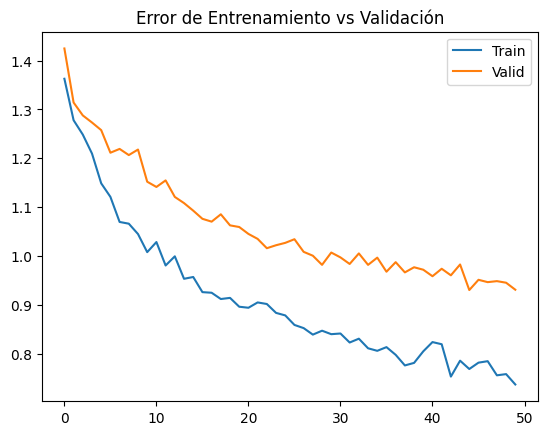

In [27]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

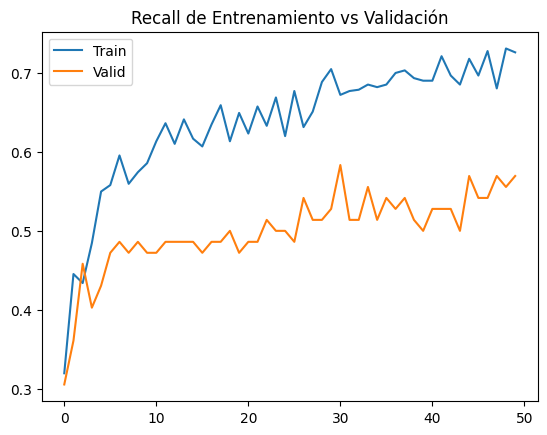

In [28]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [29]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.7259380221366882
Métrica final en validation: 0.5694444179534912
Métrica final en validation: 0.6380952596664429


### Classification Report

In [83]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.60      0.62      0.61       120
   large.cell.carcinoma       0.59      0.20      0.29        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.53      0.69      0.60        90

               accuracy                           0.64       315
              macro avg       0.68      0.63      0.63       315
           weighted avg       0.64      0.64      0.62       315



### Matriz de confusión

In [88]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

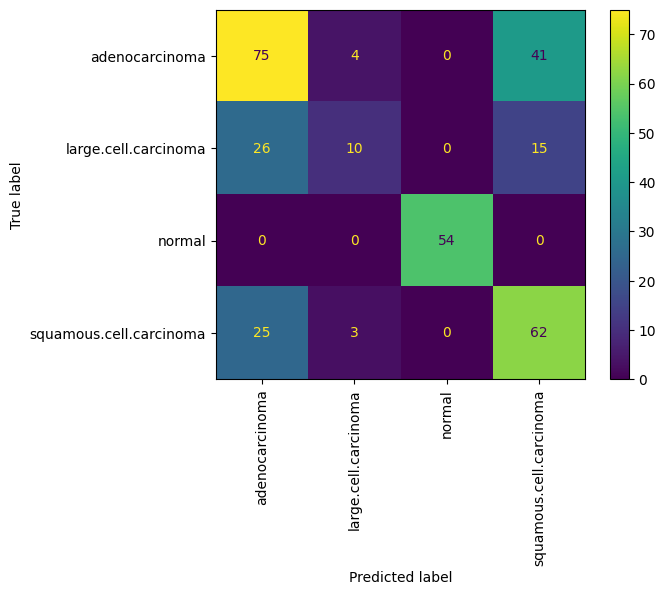

In [89]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

In [90]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

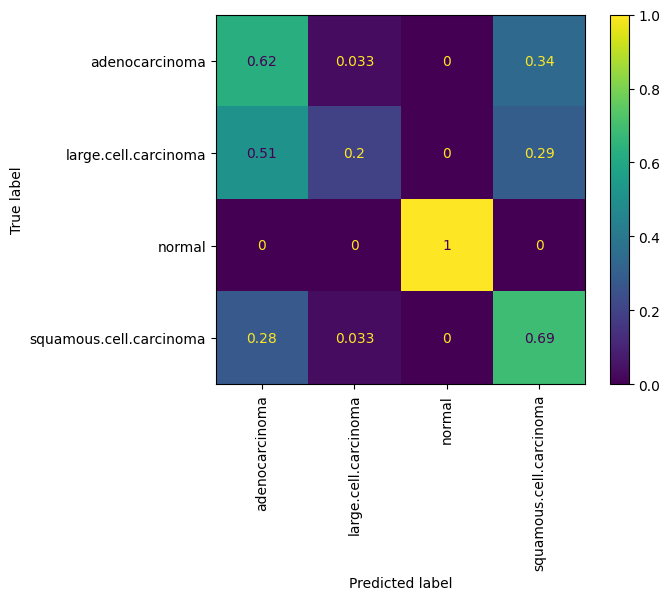

In [91]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Transformaciones lineales

### Definición del modelo

In [35]:
weights = ResNet152_Weights.IMAGENET1K_V1
resnet152_alternative_model = resnet152(weights=weights)
resnet152_alternative_model.to(device);

In [36]:
for param in resnet152_alternative_model.parameters():
    param.requires_grad = False

In [37]:
DROPOUT = 0.3

In [38]:
last_layer_in_features = resnet152_alternative_model.fc.in_features
resnet152_alternative_model.fc = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Linear(in_features=last_layer_in_features, out_features=int(last_layer_in_features/2)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/2)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 1024 -> 512
    torch.nn.Linear(in_features=int(last_layer_in_features/2), out_features=int(last_layer_in_features/4)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/4)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 512 -> 256
    torch.nn.Linear(in_features=int(last_layer_in_features/4), out_features=int(last_layer_in_features/8)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/8)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=int(last_layer_in_features/8), out_features=OUTPUTS)
  )

In [39]:
resnet152_alternative_model.to(device);

### Entrenamiento

In [40]:
model = resnet152_alternative_model

In [41]:
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

In [42]:
history_resnet152_alternative = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.2480 - Train recall: 0.4095 | Valid loss: 1.2917 - Valid recall: 0.4583
Época 2/100 | Train loss: 1.0096 - Train recall: 0.5824 | Valid loss: 1.1331 - Valid recall: 0.4583
Época 3/100 | Train loss: 0.9084 - Train recall: 0.6183 | Valid loss: 0.9894 - Valid recall: 0.4722
Época 4/100 | Train loss: 0.8240 - Train recall: 0.6786 | Valid loss: 0.9374 - Valid recall: 0.5417
Época 5/100 | Train loss: 0.7676 - Train recall: 0.6933 | Valid loss: 0.9269 - Valid recall: 0.6111
Época 6/100 | Train loss: 0.7904 - Train recall: 0.7129 | Valid loss: 0.8981 - Valid recall: 0.5972
=====No hay mejora en Valid Loss por 1 épocas.
Época 8/100 | Train loss: 0.6887 - Train recall: 0.7308 | Valid loss: 0.8406 - Valid recall: 0.6944
=====No hay mejora en Valid Loss por 1 épocas.
Época 10/100 | Train loss: 0.6162 - Train recall: 0.7667 | Valid loss: 0.8297 - Valid recall: 0.5972
Época 11/100 | Train loss: 0.6000 - Train recall: 0.7732 | Valid loss: 0.7818 - Valid recall: 0.6389
====

In [92]:
history = history_resnet152_alternative

### Gráficos

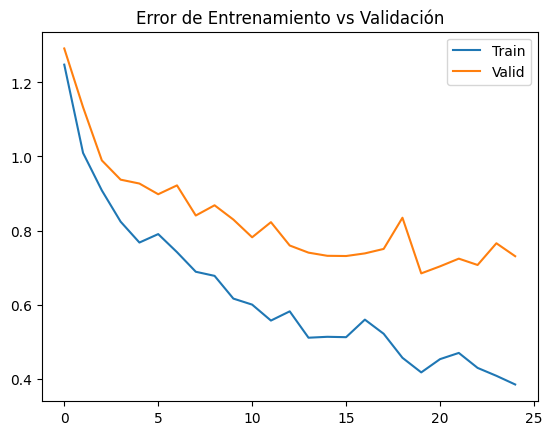

In [44]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

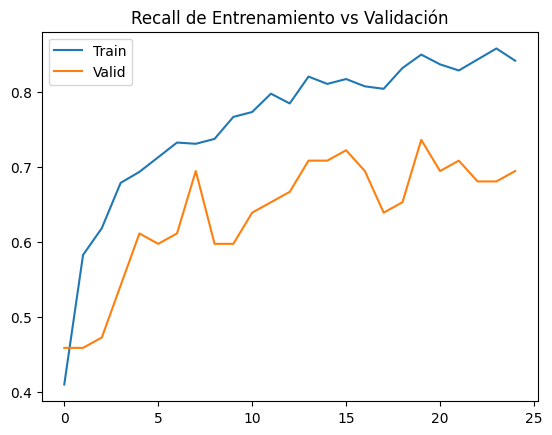

In [45]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])


### Métricas

In [46]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.8417618274688721
Métrica final en validation: 0.6944444179534912
Métrica final en validation: 0.720634937286377


### Classification Report

In [93]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.75      0.54      0.63       120
   large.cell.carcinoma       0.93      0.55      0.69        51
                 normal       0.92      1.00      0.96        54
squamous.cell.carcinoma       0.58      0.89      0.70        90

               accuracy                           0.72       315
              macro avg       0.79      0.74      0.74       315
           weighted avg       0.76      0.72      0.71       315



### Matriz de confusión

In [94]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

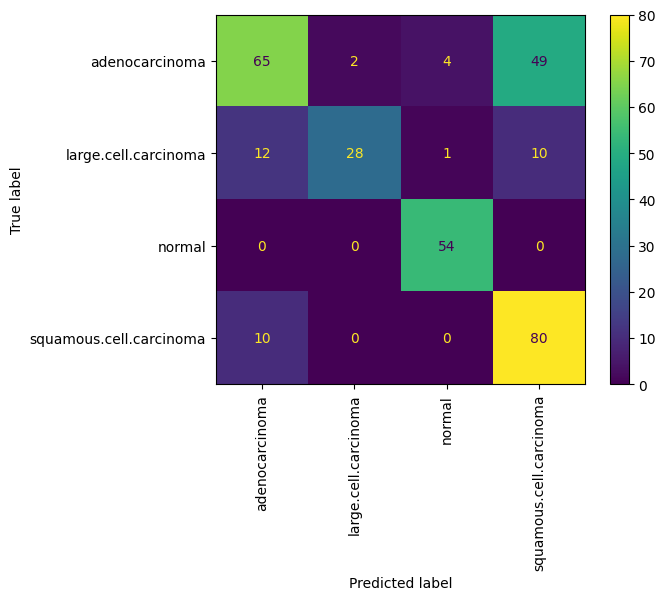

In [95]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

In [96]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

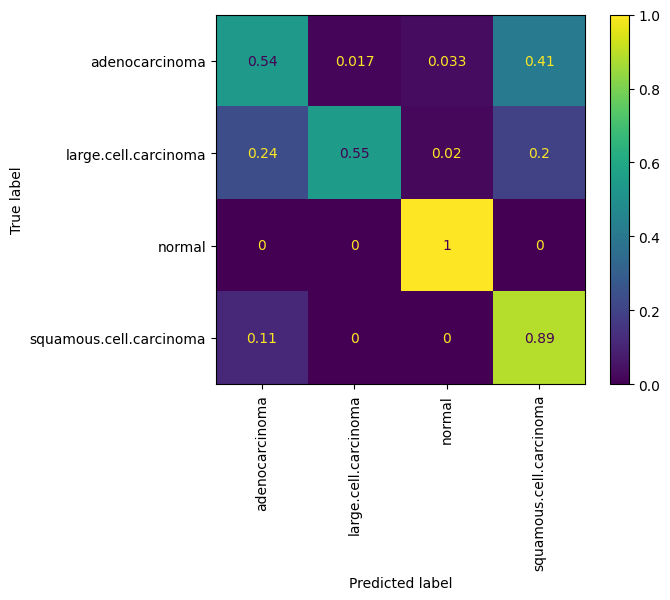

In [97]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Convoluciones en última capa

### Definición del modelo

In [ ]:
weights = ResNet152_Weights.IMAGENET1K_V1
original_resnet152 = resnet152(weights=weights)
original_resnet152.to(device);

In [ ]:
for param in original_resnet152.parameters():
    param.requires_grad = False

In [ ]:
features = torch.nn.Sequential(*list(original_resnet152.children())[:-1])

In [ ]:
class ResNet152WithCustomConvolutions(torch.nn.Module):
    def __init__(self, features, new_layer):
        super().__init__()
        self.features = features
        self.new_layer = new_layer

    def forward(self, x):
        x = self.features(x)
        x = self.new_layer(x)
        return x

In [ ]:
last_layer_in_features = original_resnet152.fc.in_features

In [ ]:
DROPOUT = 0.3

In [ ]:
seq = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Conv2d(last_layer_in_features, last_layer_in_features//2, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//2),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 1024 -> 512
    torch.nn.Conv2d(last_layer_in_features//2, last_layer_in_features//4, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//4),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 512 -> 256
    torch.nn.Conv2d(last_layer_in_features//4, last_layer_in_features//8, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//8),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    #### Adaptive Pooling 2d
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
    torch.nn.Flatten(),
    ### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=last_layer_in_features//8, out_features=OUTPUTS, bias=True)
  )

In [ ]:
resnet152CustomConvolutions = ResNet152WithCustomConvolutions(features, seq);
resnet152CustomConvolutions.to(device);

### Entrenamiento

In [ ]:
model = resnet152CustomConvolutions

In [ ]:
optimizer = torch.optim.Adam(model.new_layer.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_custom_convolutions = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Iniciando entrenamiento por 100 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/100 - Train loss 1.236857 - Train Metric 0.388750 - Valid Loss 1.313944 - Valid Metric 0.469213
    Mejora en Val Loss: (inf --> 1.3139). Guardando modelo...
Epoch: 2/100 - Train loss 1.036423 - Train Metric 0.561250 - Valid Loss 1.189922 - Valid Metric 0.422338
    Mejora en Val Loss: (1.3139 --> 1.1899). Guardando modelo...
Epoch: 3/100 - Train loss 0.921815 - Train Metric 0.637188 - Valid Loss 1.114149 - Valid Metric 0.514120
    Mejora en Val Loss: (1.1899 --> 1.1141). Guardando modelo...
Epoch: 4/100 - Train loss 0.804295 - Train Metric 0.715625 - Valid Loss 0.995626 - Valid Metric 0.560648
    Mejora en Val Loss: (1.1141 --> 0.9956). Guardando modelo...
Epoch: 5/100 - Train loss 0.811498 - Train Metric 0.671563 - Valid Loss 0.970104 - Valid Metric 0.589931
    Mejora en Val Loss: (0.9956 --> 0.9701). Guardando modelo...
Epoch: 6/100 - Train loss 0.781296 - Train Metric 0.723750 -

In [ ]:
history = history_resnet152_custom_convolutions

### Gráficos

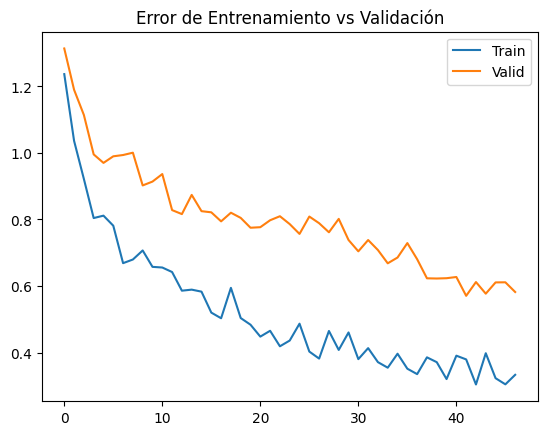

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

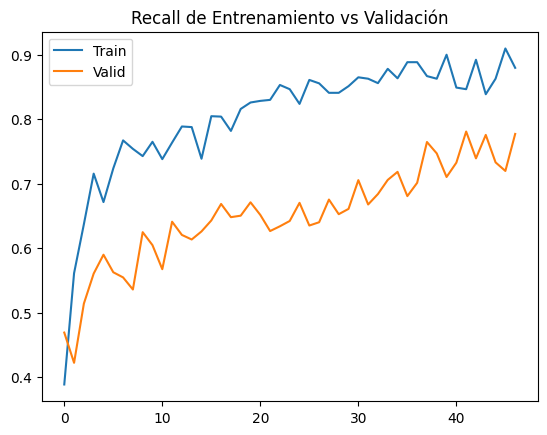

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.8796875


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

### Matriz de confusión

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

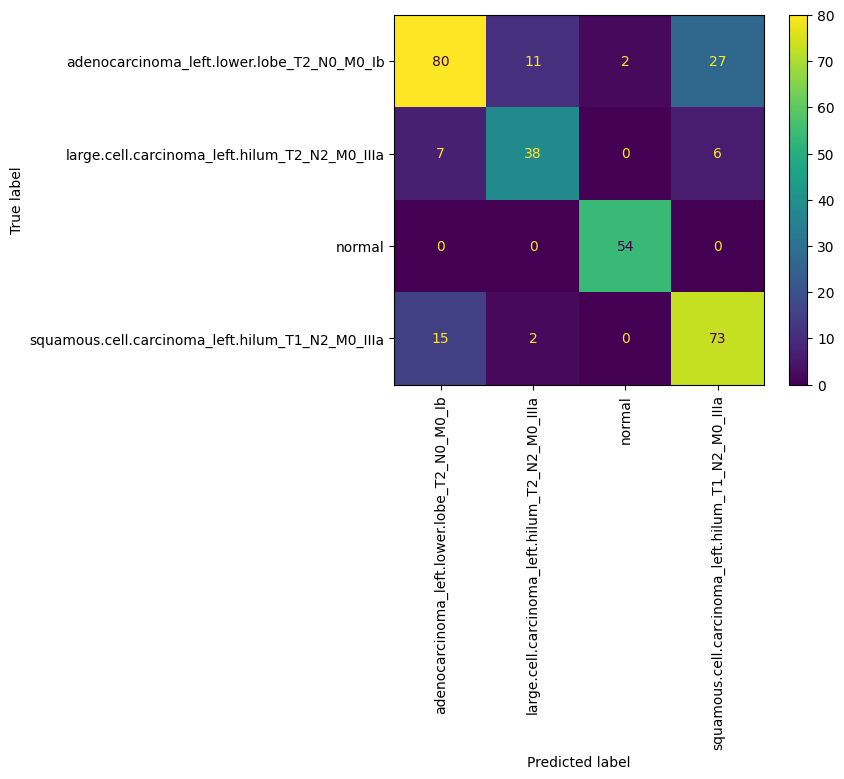

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

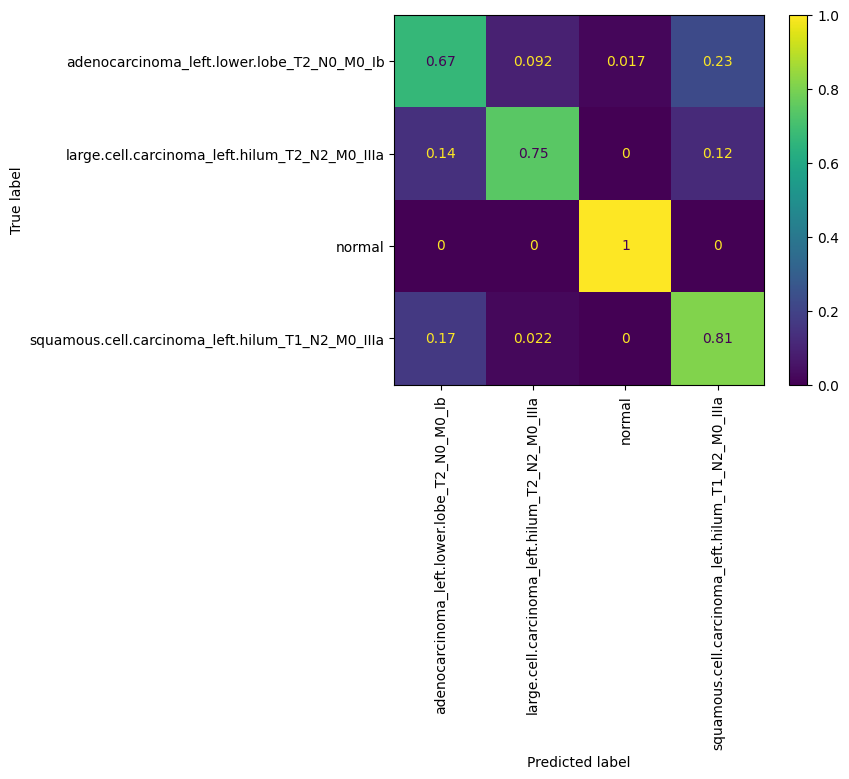

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## Resnet152 - Fine Tuning

### Definición del modelo

In [110]:
from torchvision.models import resnet152, ResNet152_Weights

weights = ResNet152_Weights.DEFAULT
resnet152_model_ft = resnet152(weights=weights);
resnet152_model_ft.to(device);

In [111]:
last_layer_in_features = resnet152_model_ft.fc.in_features
resnet152_model_ft.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

In [112]:
for param in resnet152_model_ft.parameters():
    param.requires_grad = True

### Entrenamiento

In [113]:
model = resnet152_model_ft

In [114]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [115]:
history_resnet152_ft = train_eval_loop(model=model, optimizer=optimizer,
                                       criterion=criterion, metric=metric,
                                       data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.1798 - Train recall: 0.5188 | Valid loss: 1.1999 - Valid recall: 0.5278
Época 2/100 | Train loss: 0.8007 - Train recall: 0.6998 | Valid loss: 0.9151 - Valid recall: 0.5972
Época 3/100 | Train loss: 0.5001 - Train recall: 0.8173 | Valid loss: 0.5731 - Valid recall: 0.7222
Época 4/100 | Train loss: 0.2821 - Train recall: 0.9184 | Valid loss: 0.4850 - Valid recall: 0.8056
Época 5/100 | Train loss: 0.2244 - Train recall: 0.9347 | Valid loss: 0.3655 - Valid recall: 0.8194
Época 6/100 | Train loss: 0.1722 - Train recall: 0.9396 | Valid loss: 0.3639 - Valid recall: 0.8333
Época 7/100 | Train loss: 0.0857 - Train recall: 0.9821 | Valid loss: 0.3221 - Valid recall: 0.8472
=====No hay mejora en Valid Loss por 1 épocas.
=====No hay mejora en Valid Loss por 2 épocas.
=====No hay mejora en Valid Loss por 3 épocas.
=====No hay mejora en Valid Loss por 4 épocas.
Época 12/100 | Train loss: 0.1258 - Train recall: 0.9723 | Valid loss: 0.2609 - Valid recall: 0.8611
Época 13/10

In [116]:
history = history_resnet152_ft

### Gráficos

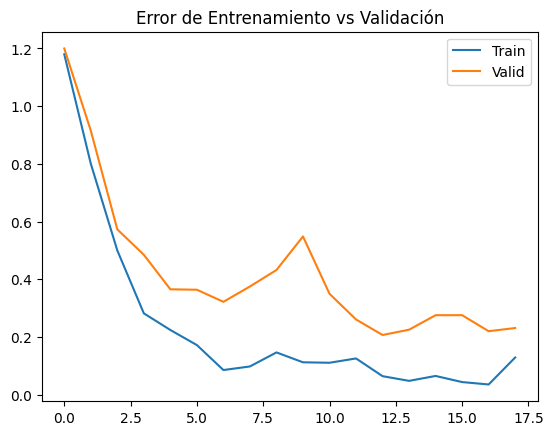

In [117]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

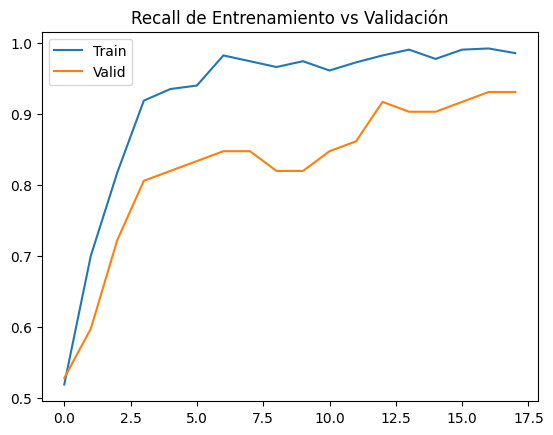

In [118]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [119]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.985318124294281
Métrica final en validation: 0.9305555820465088
Métrica final en validation: 0.9142857193946838


### Classification Report

In [120]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.96      0.81      0.88       120
   large.cell.carcinoma       0.89      0.94      0.91        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.84      1.00      0.91        90

               accuracy                           0.91       315
              macro avg       0.92      0.93      0.92       315
           weighted avg       0.92      0.91      0.91       315



### Matriz de confusión

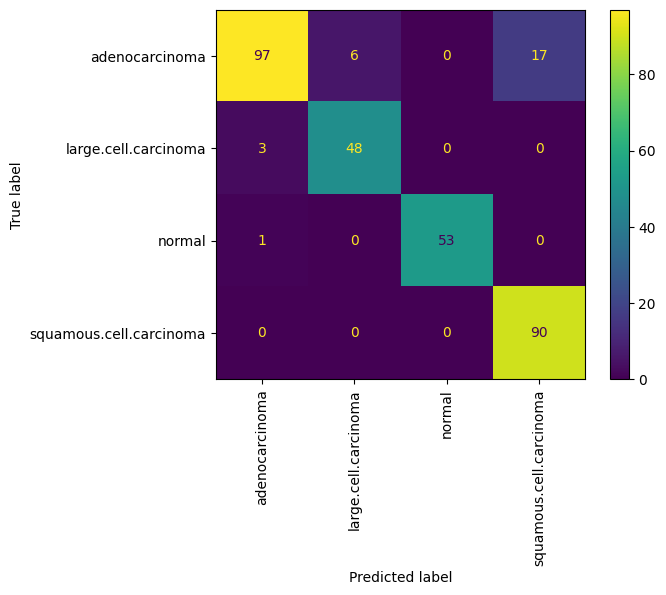

In [124]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)

### Matriz de confusión normalizada por fila

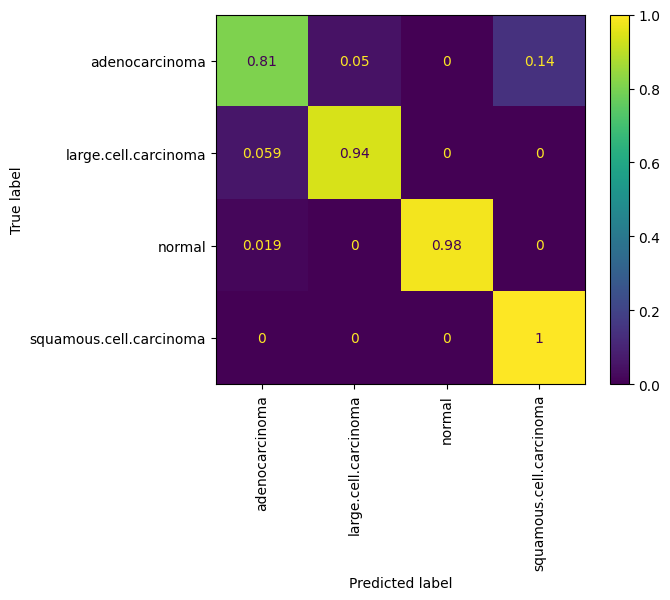

In [123]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Transformaciones lineales - Fine Tuning

### Definición del modelo

In [125]:
weights = ResNet152_Weights.DEFAULT
resnet152_lineal_ft = resnet152(weights=weights)
resnet152_lineal_ft.to(device);

In [126]:
DROPOUT = 0.3

In [127]:
last_layer_in_features = resnet152_lineal_ft.fc.in_features
resnet152_lineal_ft.fc = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Linear(in_features=last_layer_in_features, out_features=int(last_layer_in_features/2)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/2)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 1024 -> 512
    torch.nn.Linear(in_features=int(last_layer_in_features/2), out_features=int(last_layer_in_features/4)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/4)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 512 -> 256
    torch.nn.Linear(in_features=int(last_layer_in_features/4), out_features=int(last_layer_in_features/8)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/8)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=int(last_layer_in_features/8), out_features=OUTPUTS)
  )

In [128]:
for param in resnet152_model_ft.parameters():
    param.requires_grad = True

In [129]:
resnet152_lineal_ft.to(device);

### Entrenamiento

In [130]:
model = resnet152_lineal_ft

In [131]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [132]:
history_resnet152_lineal_ft = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.4001 - Train recall: 0.3132 | Valid loss: 1.3179 - Valid recall: 0.3333
Época 2/100 | Train loss: 1.0924 - Train recall: 0.5449 | Valid loss: 1.2258 - Valid recall: 0.4444
Época 3/100 | Train loss: 0.9570 - Train recall: 0.6117 | Valid loss: 1.0328 - Valid recall: 0.5417
Época 4/100 | Train loss: 0.8398 - Train recall: 0.6737 | Valid loss: 1.0299 - Valid recall: 0.5139
Época 5/100 | Train loss: 0.7268 - Train recall: 0.7080 | Valid loss: 0.9124 - Valid recall: 0.5000
Época 6/100 | Train loss: 0.6789 - Train recall: 0.7390 | Valid loss: 0.7819 - Valid recall: 0.5972
Época 7/100 | Train loss: 0.5640 - Train recall: 0.8369 | Valid loss: 0.7354 - Valid recall: 0.6528
Época 8/100 | Train loss: 0.4682 - Train recall: 0.8564 | Valid loss: 0.6352 - Valid recall: 0.6667
Época 9/100 | Train loss: 0.3255 - Train recall: 0.9152 | Valid loss: 0.5946 - Valid recall: 0.7778
Época 10/100 | Train loss: 0.3054 - Train recall: 0.9152 | Valid loss: 0.5088 - Valid recall: 0.7361

In [133]:
history = history_resnet152_lineal_ft

### Gráficos

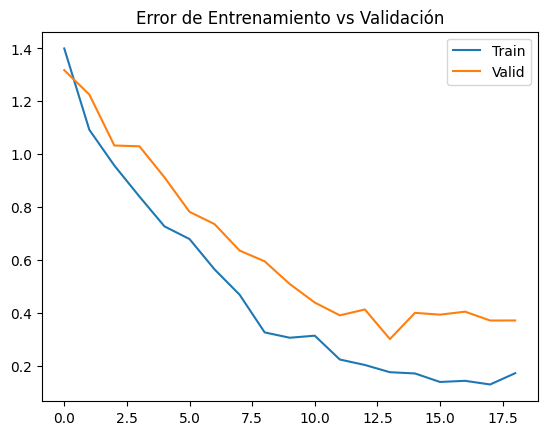

In [134]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

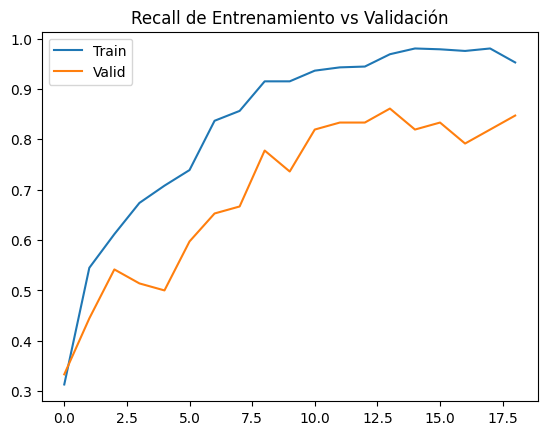

In [135]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [136]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.9526916742324829
Métrica final en validation: 0.8472222089767456
Métrica final en validation: 0.882539689540863


### Classification Report

In [137]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.86      0.87      0.86       120
   large.cell.carcinoma       0.93      0.82      0.88        51
                 normal       1.00      0.94      0.97        54
squamous.cell.carcinoma       0.83      0.90      0.86        90

               accuracy                           0.88       315
              macro avg       0.90      0.88      0.89       315
           weighted avg       0.89      0.88      0.88       315



### Matriz de confusión

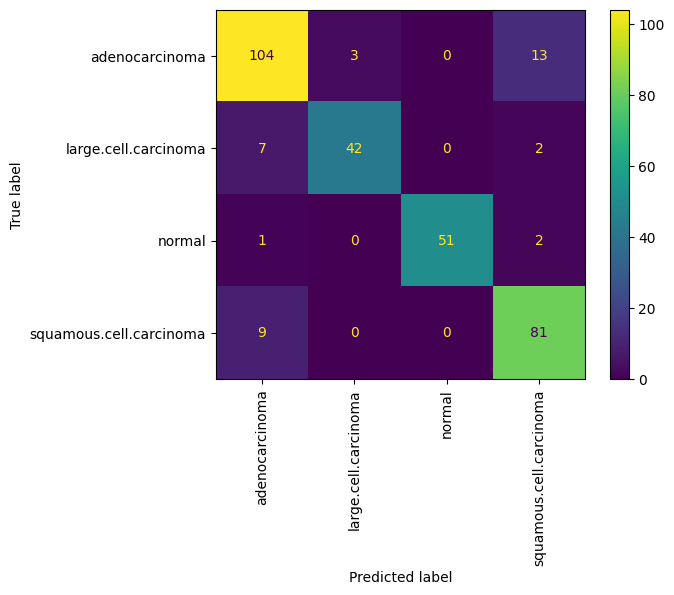

In [138]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

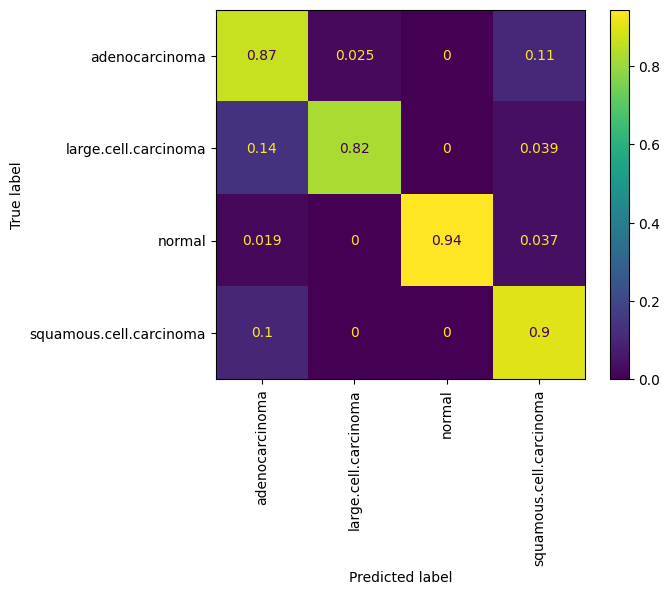

In [139]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()